In [ ]:
# Load library
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
from sklearn.metrics import mean_absolute_error, mean_squared_error

In [ ]:
# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# Function to load data
def readcsv(directory_path, file_name, column_name):
    full_path = os.path.join(directory_path, file_name)
    df = pd.read_csv(full_path)
    return df[column_name]

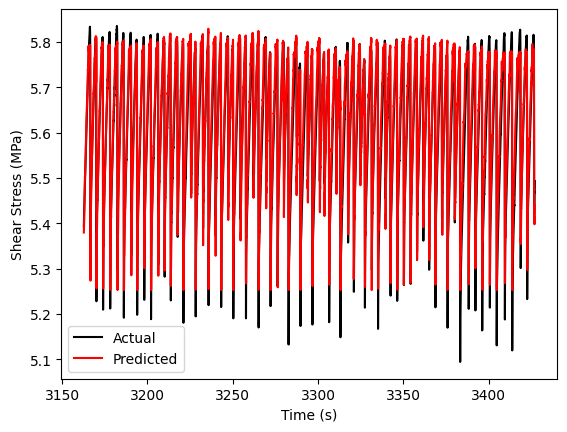

In [ ]:
# Load data: Seed 0
path_seed_0 = '/content/drive/My Drive/Colab Notebooks/Final_Features_Extraction_Codes/Uncertainty_Quantifications/XPG_L1_Reg/Seed_0/Files'
Time_Test_Seed_0 = readcsv(path_seed_0,"testing_results.csv",'Time_s')
Actual_SS_Seed_0 = readcsv(path_seed_0,"testing_results.csv",'Actual_Shear_Stress')
Predicted_SS_Seed_0 = readcsv(path_seed_0,"testing_results.csv",'Predicted_Shear_Stress')

plt.plot(Time_Test_Seed_0,Actual_SS_Seed_0,color='black',label='Actual')
plt.plot(Time_Test_Seed_0,Predicted_SS_Seed_0,color='red',label='Predicted')
plt.xlabel('Time (s)')
plt.ylabel('Shear Stress (MPa)')
plt.legend()
plt.axis('tight')
plt.show()

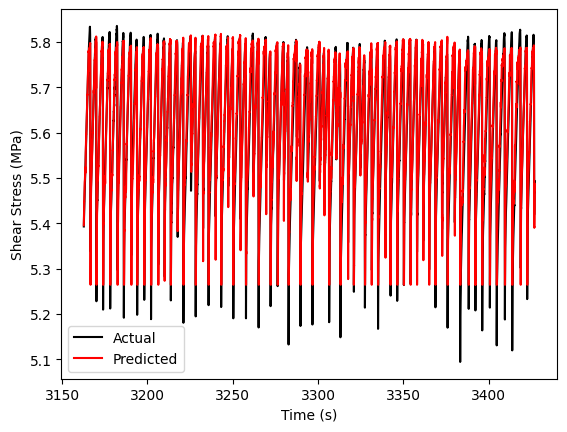

In [ ]:
# Load data: Seed 10
path_seed_10 = '/content/drive/My Drive/Colab Notebooks/Final_Features_Extraction_Codes/Uncertainty_Quantifications/XPG_L1_Reg/Seed_10/Files'
Time_Test_Seed_10 = readcsv(path_seed_10,"testing_results.csv",'Time_s')
Actual_SS_Seed_10 = readcsv(path_seed_10,"testing_results.csv",'Actual_Shear_Stress')
Predicted_SS_Seed_10 = readcsv(path_seed_10,"testing_results.csv",'Predicted_Shear_Stress')

plt.plot(Time_Test_Seed_10,Actual_SS_Seed_10,color='black',label='Actual')
plt.plot(Time_Test_Seed_10,Predicted_SS_Seed_10,color='red',label='Predicted')
plt.xlabel('Time (s)')
plt.ylabel('Shear Stress (MPa)')
plt.legend()
plt.axis('tight')
plt.show()

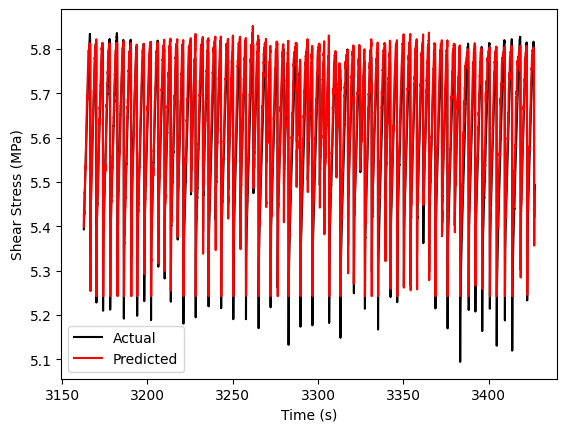

In [ ]:
# Load data: Seed 20
path_seed_20 = '/content/drive/My Drive/Colab Notebooks/Final_Features_Extraction_Codes/Uncertainty_Quantifications/XPG_L1_Reg/Seed_20/Files'
Time_Test_Seed_20 = readcsv(path_seed_20,"testing_results.csv",'Time_s')
Actual_SS_Seed_20 = readcsv(path_seed_20,"testing_results.csv",'Actual_Shear_Stress')
Predicted_SS_Seed_20 = readcsv(path_seed_20,"testing_results.csv",'Predicted_Shear_Stress')

plt.plot(Time_Test_Seed_20,Actual_SS_Seed_20,color='black',label='Actual')
plt.plot(Time_Test_Seed_20,Predicted_SS_Seed_20,color='red',label='Predicted')
plt.xlabel('Time (s)')
plt.ylabel('Shear Stress (MPa)')
plt.legend()
plt.axis('tight')
plt.show()

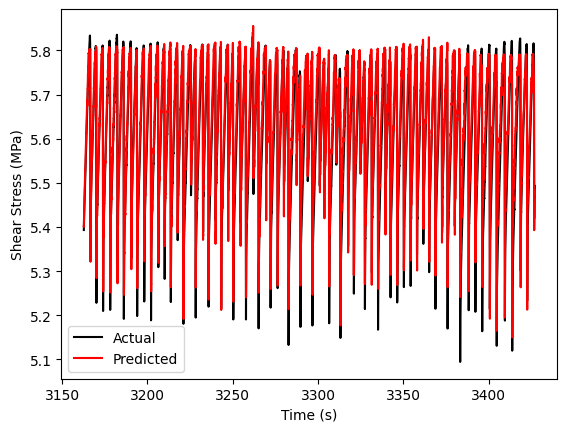

In [ ]:
# Load data: Seed 30
path_seed_30 = '/content/drive/My Drive/Colab Notebooks/Final_Features_Extraction_Codes/Uncertainty_Quantifications/XPG_L1_Reg/Seed_30/Files'
Time_Test_Seed_30 = readcsv(path_seed_30,"testing_results.csv",'Time_s')
Actual_SS_Seed_30 = readcsv(path_seed_30,"testing_results.csv",'Actual_Shear_Stress')
Predicted_SS_Seed_30 = readcsv(path_seed_30,"testing_results.csv",'Predicted_Shear_Stress')

plt.plot(Time_Test_Seed_30,Actual_SS_Seed_30,color='black',label='Actual')
plt.plot(Time_Test_Seed_30,Predicted_SS_Seed_30,color='red',label='Predicted')
plt.xlabel('Time (s)')
plt.ylabel('Shear Stress (MPa)')
plt.legend()
plt.axis('tight')
plt.show()

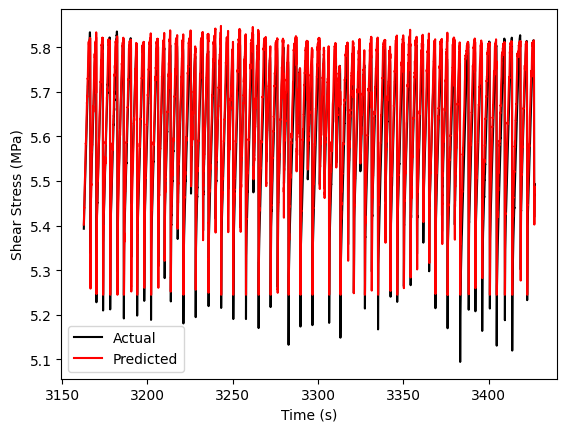

In [ ]:
# Load data: Seed 40
path_seed_40 = '/content/drive/My Drive/Colab Notebooks/Final_Features_Extraction_Codes/Uncertainty_Quantifications/XPG_L1_Reg/Seed_40/Files'
Time_Test_Seed_40 = readcsv(path_seed_40,"testing_results.csv",'Time_s')
Actual_SS_Seed_40 = readcsv(path_seed_40,"testing_results.csv",'Actual_Shear_Stress')
Predicted_SS_Seed_40 = readcsv(path_seed_40,"testing_results.csv",'Predicted_Shear_Stress')

plt.plot(Time_Test_Seed_40,Actual_SS_Seed_40,color='black',label='Actual')
plt.plot(Time_Test_Seed_40,Predicted_SS_Seed_40,color='red',label='Predicted')
plt.xlabel('Time (s)')
plt.ylabel('Shear Stress (MPa)')
plt.legend()
plt.axis('tight')
plt.show()

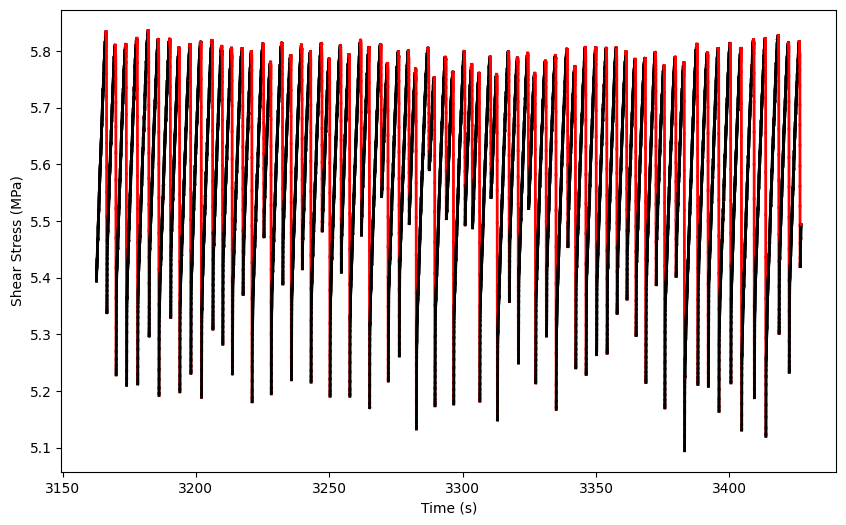

In [ ]:
# Plot Pre-failure & Co-failure Regions

# Assuming Actual_SS_Seed_0 and Time_Test_Seed_0 are already defined as pandas Series
actual_ss_array = Actual_SS_Seed_0.to_numpy()
time_array = Time_Test_Seed_0.to_numpy()

if len(actual_ss_array) < 2:
    print("Not enough data points to determine trends.")
else:
    plt.figure(figsize=(10, 6)) # Entire
    # plt.figure(figsize=(3, 3)) # Zoom
    has_pre_failure_label = False
    has_co_failure_label = False

    # Iterate through the data points to identify and plot segments
    for i in range(1, len(actual_ss_array)):
        if actual_ss_array[i] > actual_ss_array[i-1]:
            # Increasing trend (pre-failure)
            label = 'Pre-failure (Increasing)' if not has_pre_failure_label else None
            plt.plot(time_array[i-1:i+1], actual_ss_array[i-1:i+1],
                     color='black', linewidth=2, label=label)
            if not has_pre_failure_label:
                has_pre_failure_label = True
        elif actual_ss_array[i] < actual_ss_array[i-1]:
            # Decreasing trend (co-failure)
            label = 'Co-failure (Decreasing)' if not has_co_failure_label else None
            plt.plot(time_array[i-1:i+1], actual_ss_array[i-1:i+1],
                     color='red', linewidth=2, label=label)
            if not has_co_failure_label:
                has_co_failure_label = True
        else:
            # If actual_ss_array[i] == actual_ss_array[i-1] (flat section),
            # we'll categorize it as 'pre-failure' by default as a tie-breaker.
            label = 'Pre-failure (Increasing)' if not has_pre_failure_label else None
            plt.plot(time_array[i-1:i+1], actual_ss_array[i-1:i+1],
                     color='black', linewidth=2, label=label)
            if not has_pre_failure_label:
                has_pre_failure_label = True

    plt.xlabel('Time (s)')
    plt.ylabel('Shear Stress (MPa)')
    # plt.legend()
    # plt.title('Pre-failure and Co-failure Regions on Actual_SS_Seed_0 (Cyclic Data)')
    plt.axis('tight')
    # plt.xlim([3162, 3175])
    plt.show()


In [ ]:
# Compute MAE & RMSE for the Regions

# List to store results for each seed
pre_failure_mae_scores = []
pre_failure_rmse_scores = []
co_failure_mae_scores = []
co_failure_rmse_scores = []

seed_values = [0, 10, 20, 30, 40]

for seed in seed_values:
    # Dynamically get the actual and predicted shear stress data for the current seed
    actual_ss_var_name = f'Actual_SS_Seed_{seed}'
    predicted_ss_var_name = f'Predicted_SS_Seed_{seed}'

    # Check if variables exist in the global scope
    if actual_ss_var_name not in globals() or predicted_ss_var_name not in globals():
        print(f"Warning: Data for seed {seed} ({actual_ss_var_name} or {predicted_ss_var_name}) not found. Skipping.")
        continue

    actual_ss_array = globals()[actual_ss_var_name].to_numpy()
    predicted_ss_array = globals()[predicted_ss_var_name].to_numpy()

    if len(actual_ss_array) < 2:
        print(f"Not enough data points for seed {seed} to determine trends. Skipping.")
        continue

    # Lists to hold actual and predicted values for each region for the current seed
    current_pre_failure_actual = []
    current_pre_failure_predicted = []
    current_co_failure_actual = []
    current_co_failure_predicted = []

    # Identify regions based on increasing/decreasing actual shear stress
    for i in range(1, len(actual_ss_array)):
        # Current point and previous point
        current_actual = actual_ss_array[i]
        previous_actual = actual_ss_array[i-1]

        current_predicted = predicted_ss_array[i]
        previous_predicted = predicted_ss_array[i-1]

        if current_actual >= previous_actual:
            # Increasing or flat trend (pre-failure)
            current_pre_failure_actual.extend([previous_actual, current_actual])
            current_pre_failure_predicted.extend([previous_predicted, current_predicted])
        else:
            # Decreasing trend (co-failure)
            current_co_failure_actual.extend([previous_actual, current_actual])
            current_co_failure_predicted.extend([previous_predicted, current_predicted])

    # Convert lists to numpy arrays for metric calculation
    current_pre_failure_actual = np.array(current_pre_failure_actual)
    current_pre_failure_predicted = np.array(current_pre_failure_predicted)
    current_co_failure_actual = np.array(current_co_failure_actual)
    current_co_failure_predicted = np.array(current_co_failure_predicted)

    # Calculate MAE and RMSE for pre-failure region for current seed
    if len(current_pre_failure_actual) > 0:
        mae_pre_failure = mean_absolute_error(current_pre_failure_actual, current_pre_failure_predicted)
        rmse_pre_failure = np.sqrt(mean_squared_error(current_pre_failure_actual, current_pre_failure_predicted))
        pre_failure_mae_scores.append(mae_pre_failure)
        pre_failure_rmse_scores.append(rmse_pre_failure)
    else:
        print(f"No pre-failure data found for seed {seed}.")

    # Calculate MAE and RMSE for co-failure region for current seed
    if len(current_co_failure_actual) > 0:
        mae_co_failure = mean_absolute_error(current_co_failure_actual, current_co_failure_predicted)
        rmse_co_failure = np.sqrt(mean_squared_error(current_co_failure_actual, current_co_failure_predicted))
        co_failure_mae_scores.append(mae_co_failure)
        co_failure_rmse_scores.append(rmse_co_failure)
    else:
        print(f"No co-failure data found for seed {seed}.")

# Convert lists to numpy arrays for overall statistics
pre_failure_mae_scores = np.array(pre_failure_mae_scores)
pre_failure_rmse_scores = np.array(pre_failure_rmse_scores)
co_failure_mae_scores = np.array(co_failure_mae_scores)
co_failure_rmse_scores = np.array(co_failure_rmse_scores)

# Report mean ± standard deviation for pre-failure regions
print("\n--- Pre-failure Region Statistics (Mean ± Std Dev) ---")
if len(pre_failure_mae_scores) > 0:
    print(f"MAE: {np.mean(pre_failure_mae_scores):.4f} ± {np.std(pre_failure_mae_scores):.4f}")
    print(f"RMSE: {np.mean(pre_failure_rmse_scores):.4f} ± {np.std(pre_failure_rmse_scores):.4f}")
else:
    print("No pre-failure data processed.")

# Report mean ± standard deviation for co-failure regions
print("\n--- Co-failure Region Statistics (Mean ± Std Dev) ---")
if len(co_failure_mae_scores) > 0:
    print(f"MAE: {np.mean(co_failure_mae_scores):.4f} ± {np.std(co_failure_mae_scores):.4f}")
    print(f"RMSE: {np.mean(co_failure_rmse_scores):.4f} ± {np.std(co_failure_rmse_scores):.4f}")
else:
    print("No co-failure data processed.")



--- Pre-failure Region Statistics (Mean ± Std Dev) ---
MAE: 0.0301 ± 0.0046
RMSE: 0.0375 ± 0.0047

--- Co-failure Region Statistics (Mean ± Std Dev) ---
MAE: 0.0410 ± 0.0020
RMSE: 0.0592 ± 0.0025
